# Market Efficiency in College Football Betting
### JEM207 - Data Processing in Python

This project analyzes the efficiency of betting markets in college football using historical game data from the College Football Data API (2020–2023). The goal is to evaluate whether the betting spread accurately predicts game outcomes — and whether the market is informationally efficient.

**Key questions:**
- Do favorites cover the spread as often as expected?
- Is there a systematic home team bias in the market?
- Does accuracy vary by conference, week, or spread size?

## 1. Setup

### API Key Instructions

This project uses the [College Football Data API](https://collegefootballdata.com).
To run this notebook, you need a free API key:

1. Go to [collegefootballdata.com](https://collegefootballdata.com) and register for a free account
2. Copy your API key from your account page
3. Create a file called `config.py` in the same folder as this notebook with the following content:

```python
API_KEY = "your_api_key_here"
```

4. Run the notebook from top to bottom

> **Note:** `config.py` is listed in `.gitignore` and will not be pushed to GitHub. Each user must create their own.

In [2]:
%pip install requests pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

# load API key from config.py
# create a config.py file in this folder with: API_KEY = "your_key_here"
try:
    from config import API_KEY
    print("API key loaded from config.py")
except ImportError:
    raise ImportError(
        "config.py not found. Please create a config.py file in this folder with:\n"
        '    API_KEY = "your_api_key_here"\n'
        "Get a free key at: https://collegefootballdata.com"
    )

HEADERS = {"Authorization": f"Bearer {API_KEY}"}
BASE_URL = "https://api.collegefootballdata.com"

print("Libraries loaded. Ready to go!")

API key loaded from config.py
Libraries loaded. Ready to go!


## 2. Data Collection

We pull 4 seasons (2020–2023) of betting lines from the College Football Data API and save the raw JSON to a dedicated `raw_data/` folder for reproducibility.

In [4]:
# create raw_data folder if it doesn't exist
os.makedirs("raw_data", exist_ok=True)
print("raw_data/ folder ready")

raw_data/ folder ready


In [5]:
import time

seasons = [2020, 2021, 2022, 2023]
all_lines = []

for year in seasons:
    # if we already have the raw JSON, load it instead of hitting the API
    json_path = f"raw_data/lines_{year}.json"
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            data = json.load(f)
        print(f"{year}: loaded {len(data)} games from raw_data/lines_{year}.json")
        all_lines.extend(data)
        continue

    # otherwise download from API with retry
    for attempt in range(5):
        try:
            response = requests.get(
                f"{BASE_URL}/lines",
                headers=HEADERS,
                params={"year": year, "seasonType": "regular"},
                timeout=60
            )
            if response.status_code == 200:
                data = response.json()
                if len(data) > 100:  # sanity check — reject suspiciously small responses
                    all_lines.extend(data)
                    with open(json_path, "w") as f:
                        json.dump(data, f, indent=2)
                    print(f"{year}: got {len(data)} games — saved to {json_path}")
                    time.sleep(10)  # wait between seasons
                    break
                else:
                    print(f"{year}: only got {len(data)} games, retrying...")
                    time.sleep(10)
            else:
                print(f"{year}: bad status {response.status_code}, retrying...")
                time.sleep(10)
        except Exception as e:
            print(f"{year}: attempt {attempt+1} failed — {e}")
            time.sleep(10)
    else:
        print(f"{year}: all attempts failed! Try running this cell again later.")

print(f"\ntotal games collected: {len(all_lines)}")
print("\ngames per season:")
for year in seasons:
    count = sum(1 for g in all_lines if g.get('season') == year)
    print(f"  {year}: {count} games")


2020: got 542 games — saved to raw_data/lines_2020.json
2021: got 849 games — saved to raw_data/lines_2021.json
2022: got 1417 games — saved to raw_data/lines_2022.json
2023: got 1350 games — saved to raw_data/lines_2023.json

total games collected: 4158

games per season:
  2020: 542 games
  2021: 849 games
  2022: 1417 games
  2023: 1350 games


## 3. Data Cleaning

Flatten the nested JSON into a clean DataFrame and filter for consensus lines only.

In [6]:
rows = []

for game in all_lines:
    lines = game.get("lines", [])

    # try consensus first, fall back to any available line
    consensus = next((l for l in lines if l.get("provider") == "consensus"), None)
    line = consensus if consensus else (lines[0] if lines else None)

    if not line:
        continue

    rows.append({
        "season": game["season"],
        "week": game["week"],
        "home_team": game["homeTeam"],
        "away_team": game["awayTeam"],
        "home_conference": game.get("homeConference"),
        "away_conference": game.get("awayConference"),
        "home_score": game["homeScore"],
        "away_score": game["awayScore"],
        "spread": line.get("spread"),
        "over_under": line.get("overUnder"),
        "home_moneyline": line.get("homeMoneyline"),
        "away_moneyline": line.get("awayMoneyline"),
    })

df = pd.DataFrame(rows)
print(f"dataframe shape: {df.shape}")
print(f"\ngames per season:")
print(df["season"].value_counts().sort_index())
df.head()

dataframe shape: (4150, 12)

games per season:
season
2020     541
2021     849
2022    1413
2023    1347
Name: count, dtype: int64


,season,week,home_team,away_team,home_conference,away_conference,home_score,away_score,spread,over_under,home_moneyline,away_moneyline
0,2020,11,Florida,Arkansas,SEC,SEC,63,35,-17.0,62.0,NaN,NaN
1,2020,12,Air Force,New Mexico,Mountain West,Mountain West,28,0,-8.0,55.5,NaN,NaN
2,2020,12,Alabama,Kentucky,SEC,SEC,63,3,-31.5,57.5,NaN,NaN
3,2020,12,Ohio State,Indiana,Big Ten,Big Ten,42,35,-21.0,67.5,NaN,NaN
4,2020,12,Arkansas,LSU,SEC,SEC,24,27,1.5,65.0,NaN,NaN


In [7]:
# convert to numbers
df["spread"] = pd.to_numeric(df["spread"], errors="coerce")
df["over_under"] = pd.to_numeric(df["over_under"], errors="coerce")
df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")

# drop rows missing scores or spread
df = df.dropna(subset=["spread", "home_score", "away_score"])

print(f"clean dataframe: {df.shape}")
print(f"\nmissing values:")
print(df.isnull().sum())

clean dataframe: (4147, 12)

missing values:
season                0
week                  0
home_team             0
away_team             0
home_conference       0
away_conference       0
home_score            0
away_score            0
spread                0
over_under           33
home_moneyline     3545
away_moneyline     3555
dtype: int64


In [8]:
# add calculated columns
df["actual_margin"] = df["home_score"] - df["away_score"]
df["total_points"] = df["home_score"] + df["away_score"]
df["home_covered"] = df["actual_margin"] > df["spread"]
df["over_hit"] = df["total_points"] > df["over_under"]
df["spread_error"] = df["actual_margin"] - df["spread"]

# spread group classification
def spread_group(spread):
    if spread <= -14:
        return "Big Home Favorite"
    elif spread < 0:
        return "Small Home Favorite"
    elif spread == 0:
        return "Even Game"
    elif spread < 14:
        return "Small Home Underdog"
    else:
        return "Big Home Underdog"

df["spread_group"] = df["spread"].apply(spread_group)

# save cleaned data
df.to_csv("cfb_cleaned_data.csv", index=False)
print(f"saved cfb_cleaned_data.csv with {len(df)} rows")
df.head()

saved cfb_cleaned_data.csv with 4147 rows


,season,week,home_team,away_team,home_conference,away_conference,home_score,away_score,spread,over_under,home_moneyline,away_moneyline,actual_margin,total_points,home_covered,over_hit,spread_error,spread_group
0,2020,11,Florida,Arkansas,SEC,SEC,63,35,-17.0,62.0,NaN,NaN,28,98,True,True,45.0,Big Home Favorite
1,2020,12,Air Force,New Mexico,Mountain West,Mountain West,28,0,-8.0,55.5,NaN,NaN,28,28,True,False,36.0,Small Home Favorite
2,2020,12,Alabama,Kentucky,SEC,SEC,63,3,-31.5,57.5,NaN,NaN,60,66,True,True,91.5,Big Home Favorite
3,2020,12,Ohio State,Indiana,Big Ten,Big Ten,42,35,-21.0,67.5,NaN,NaN,7,77,True,True,28.0,Big Home Favorite
4,2020,12,Arkansas,LSU,SEC,SEC,24,27,1.5,65.0,NaN,NaN,-3,51,False,False,-4.5,Small Home Underdog


## 4. Basic Analysis

### 4.1 Overall Cover Rate

In [9]:
cover_rate = df["home_covered"].mean() * 100
over_rate = df["over_hit"].mean() * 100

print(f"Home team cover rate: {cover_rate:.1f}%")
print(f"Over hit rate: {over_rate:.1f}%")
print(f"Total games analyzed: {len(df)}")

Home team cover rate: 62.4%
Over hit rate: 48.6%
Total games analyzed: 4147


The home team covers the spread approximately 62% of the time. In an efficient betting market this value would be expected to be close to 50%, suggesting a possible home team bias.

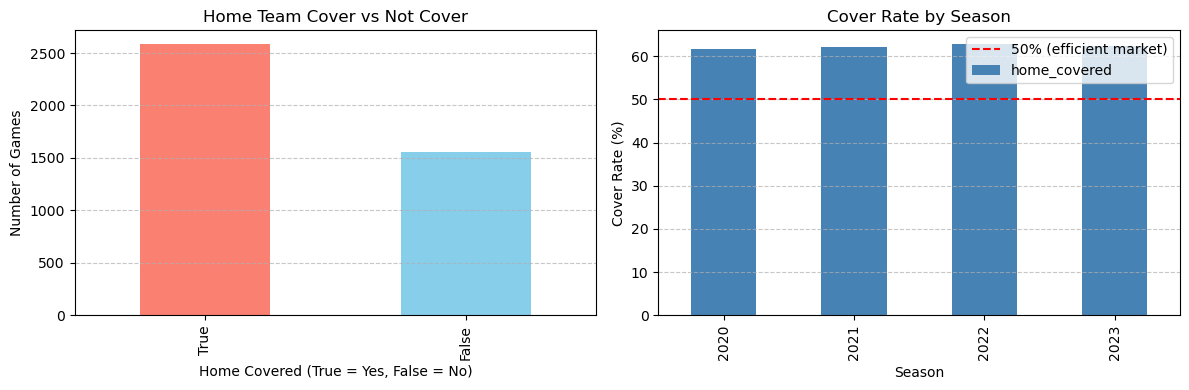

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# cover rate bar chart
cover_counts = df["home_covered"].value_counts()
cover_counts.plot(kind="bar", color=["salmon", "skyblue"], ax=axes[0])
axes[0].set_title("Home Team Cover vs Not Cover")
axes[0].set_xlabel("Home Covered (True = Yes, False = No)")
axes[0].set_ylabel("Number of Games")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# cover rate by season
season_cover = df.groupby("season")["home_covered"].mean() * 100
season_cover.plot(kind="bar", color="steelblue", ax=axes[1])
axes[1].set_title("Cover Rate by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Cover Rate (%)")
axes[1].axhline(50, color="red", linestyle="--", label="50% (efficient market)")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("raw_data/cover_rate_overview.png", dpi=150)
plt.show()

### 4.2 Spread Error Analysis

In [11]:
print(f"Average spread: {df['spread'].mean():.2f}")
print(f"Average actual margin: {df['actual_margin'].mean():.2f}")
print(f"Average spread error: {df['spread_error'].mean():.2f}")

Average spread: -6.03
Average actual margin: 5.82
Average spread error: 11.85


The average spread error is approximately 11.8. Since spread error is calculated as (actual margin - predicted spread), a positive value means the home team performs better than expected. This is consistent with the 62% cover rate.

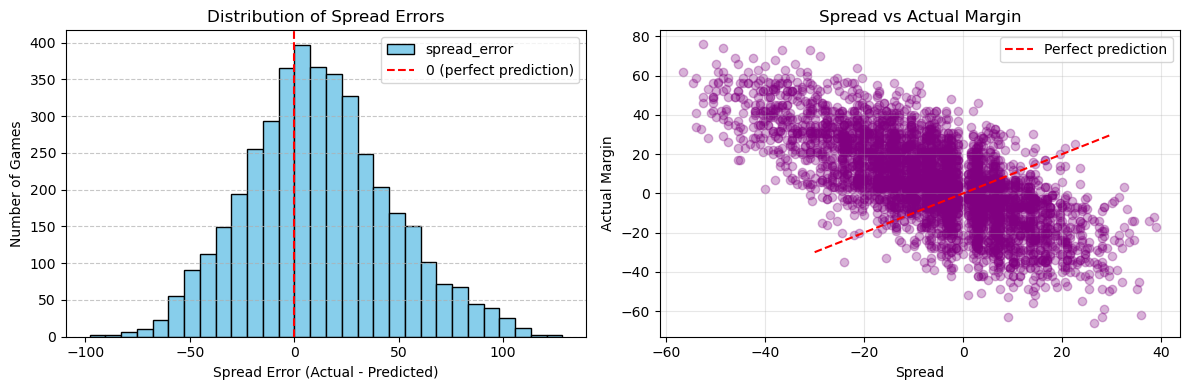

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# spread error histogram
df["spread_error"].plot(kind="hist", bins=30, color="skyblue", edgecolor="black", ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", label="0 (perfect prediction)")
axes[0].set_title("Distribution of Spread Errors")
axes[0].set_xlabel("Spread Error (Actual - Predicted)")
axes[0].set_ylabel("Number of Games")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# spread vs actual margin scatter
axes[1].scatter(df["spread"], df["actual_margin"], alpha=0.3, color="purple")
axes[1].plot([-30, 30], [-30, 30], color="red", linestyle="--", label="Perfect prediction")
axes[1].set_title("Spread vs Actual Margin")
axes[1].set_xlabel("Spread")
axes[1].set_ylabel("Actual Margin")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("raw_data/spread_error_analysis.png", dpi=150)
plt.show()

### 4.3 Cover Rate by Spread Group

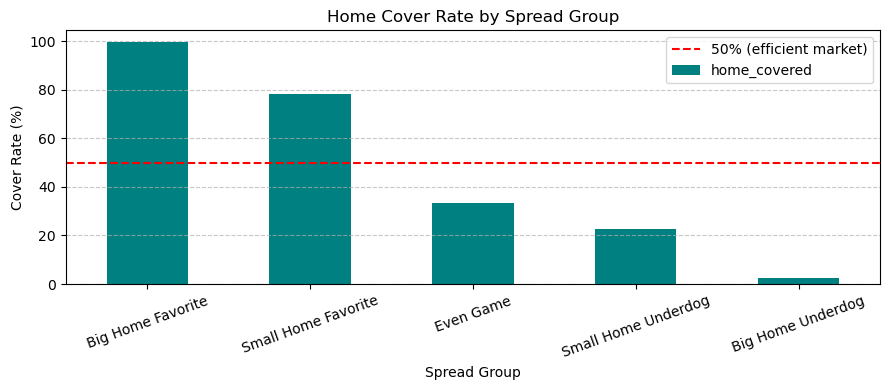

spread_group
Big Home Favorite      99.421965
Small Home Favorite    78.291317
Even Game              33.333333
Small Home Underdog    22.621185
Big Home Underdog       2.597403
Name: home_covered, dtype: float64


In [13]:
group_order = ["Big Home Favorite", "Small Home Favorite", "Even Game", "Small Home Underdog", "Big Home Underdog"]
group_cover = df.groupby("spread_group")["home_covered"].mean() * 100
group_cover = group_cover.reindex(group_order)

plt.figure(figsize=(9, 4))
group_cover.plot(kind="bar", color="teal")
plt.axhline(50, color="red", linestyle="--", label="50% (efficient market)")
plt.title("Home Cover Rate by Spread Group")
plt.xlabel("Spread Group")
plt.ylabel("Cover Rate (%)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("raw_data/cover_by_spread_group.png", dpi=150)
plt.show()

print(group_cover)

### 4.4 Cover Rate by Week

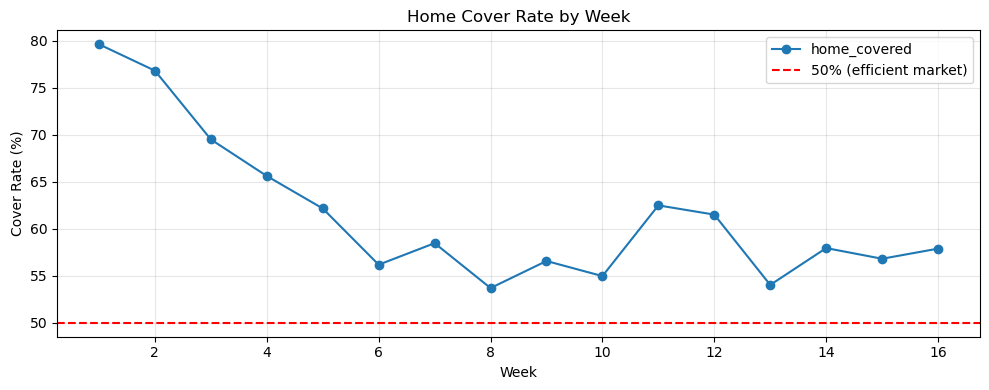

In [14]:
week_cover = df.groupby("week")["home_covered"].mean() * 100

plt.figure(figsize=(10, 4))
week_cover.plot(marker="o")
plt.axhline(50, color="red", linestyle="--", label="50% (efficient market)")
plt.title("Home Cover Rate by Week")
plt.xlabel("Week")
plt.ylabel("Cover Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("raw_data/cover_by_week.png", dpi=150)
plt.show()

## 5. Conference Analysis

Which conferences have the most and least efficient betting markets?

In [15]:
# only keep games where home team conference is known
df_conf = df.dropna(subset=["home_conference"])

# cover rate and game count by conference
conf_stats = df_conf.groupby("home_conference").agg(
    games=("home_covered", "count"),
    cover_rate=("home_covered", "mean"),
    avg_spread_error=("spread_error", "mean")
).reset_index()

conf_stats["cover_rate"] = conf_stats["cover_rate"] * 100

# filter to conferences with at least 30 games
conf_stats = conf_stats[conf_stats["games"] >= 30].sort_values("cover_rate", ascending=False)

print(conf_stats.to_string(index=False))

  home_conference  games  cover_rate  avg_spread_error
              SEC    373   69.973190         21.269437
           Big 12    282   68.439716         17.810284
 FBS Independents    139   67.625899         16.622302
              ACC    364   67.032967         15.289835
         Sun Belt    288   65.972222         12.135417
             SWAC     99   65.656566          5.242424
          Big Ten    343   64.723032         14.406706
             MVFC    107   64.485981         13.177570
              CAA    129   64.341085          9.236434
           Pac-12    274   62.043796         12.735401
American Athletic    277   61.371841         11.658845
              UAC     30   60.000000         10.200000
          Big Sky    110   59.090909         10.981818
   Conference USA    259   58.687259          9.598456
              Ivy     79   58.227848          8.727848
     Mid-American    239   57.322176          8.010460
          Pioneer     86   56.976744          1.674419
         S

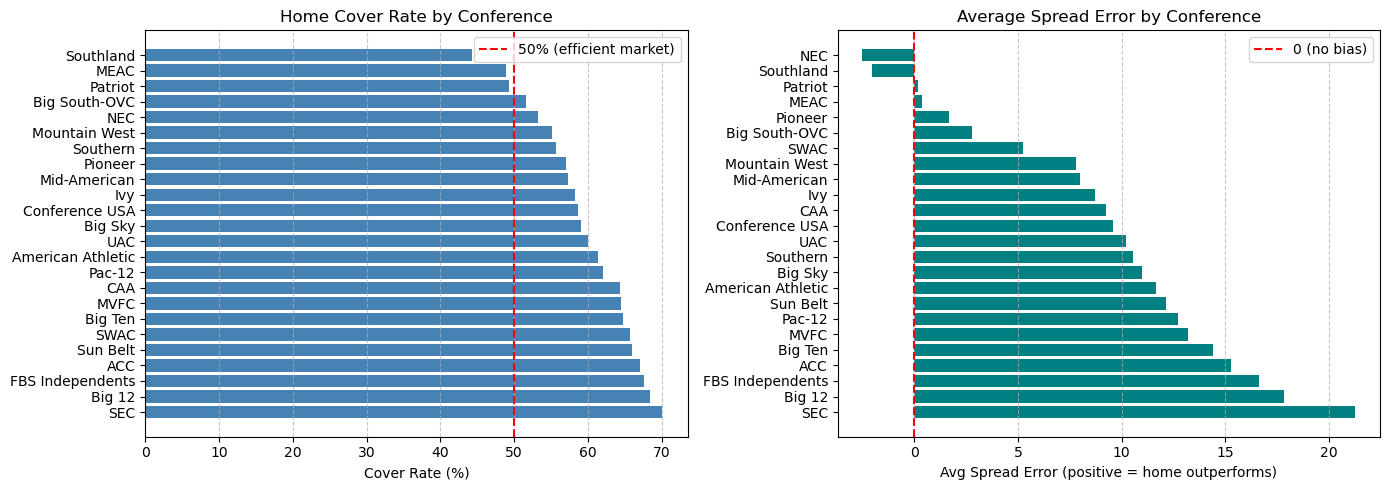

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# cover rate by conference
axes[0].barh(conf_stats["home_conference"], conf_stats["cover_rate"], color="steelblue")
axes[0].axvline(50, color="red", linestyle="--", label="50% (efficient market)")
axes[0].set_title("Home Cover Rate by Conference")
axes[0].set_xlabel("Cover Rate (%)")
axes[0].legend()
axes[0].grid(axis="x", linestyle="--", alpha=0.7)

# average spread error by conference
conf_sorted_err = conf_stats.sort_values("avg_spread_error", ascending=False)
axes[1].barh(conf_sorted_err["home_conference"], conf_sorted_err["avg_spread_error"], color="teal")
axes[1].axvline(0, color="red", linestyle="--", label="0 (no bias)")
axes[1].set_title("Average Spread Error by Conference")
axes[1].set_xlabel("Avg Spread Error (positive = home outperforms)")
axes[1].legend()
axes[1].grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("raw_data/conference_analysis.png", dpi=150)
plt.show()

### 5.2 SEC & Big Ten vs Everyone Else

The SEC and Big Ten are the two most-watched and most-bet conferences in college football. We compare their betting market efficiency against all other conferences to see if higher-profile games are priced more accurately.

In [17]:
# tag each game by conference tier
power_conferences = ["SEC", "Big Ten"]

def conference_tier(conf):
    if conf in ["SEC", "Big Ten"]:
        return conf
    elif conf in ["ACC", "Big 12", "Pac-12"]:
        return "Other Power 5"
    elif conf is None:
        return "Unknown"
    else:
        return "Group of 5 / Ind"

df["conf_tier"] = df["home_conference"].apply(conference_tier)

tier_stats = df[df["conf_tier"] != "Unknown"].groupby("conf_tier").agg(
    games=("home_covered", "count"),
    cover_rate=("home_covered", "mean"),
    avg_spread_error=("spread_error", "mean"),
    avg_spread=("spread", "mean"),
    avg_actual_margin=("actual_margin", "mean")
).reset_index()

tier_stats["cover_rate"] = tier_stats["cover_rate"] * 100
tier_stats = tier_stats.sort_values("cover_rate", ascending=False)

print(tier_stats.to_string(index=False))

       conf_tier  games  cover_rate  avg_spread_error  avg_spread  avg_actual_margin
             SEC    373   69.973190         21.269437  -10.585791          10.683646
   Other Power 5    920   65.978261         15.301630   -7.517935           7.783696
         Big Ten    343   64.723032         14.406706   -7.972303           6.434402
Group of 5 / Ind   2511   59.617682          8.835922   -4.547989           4.287933


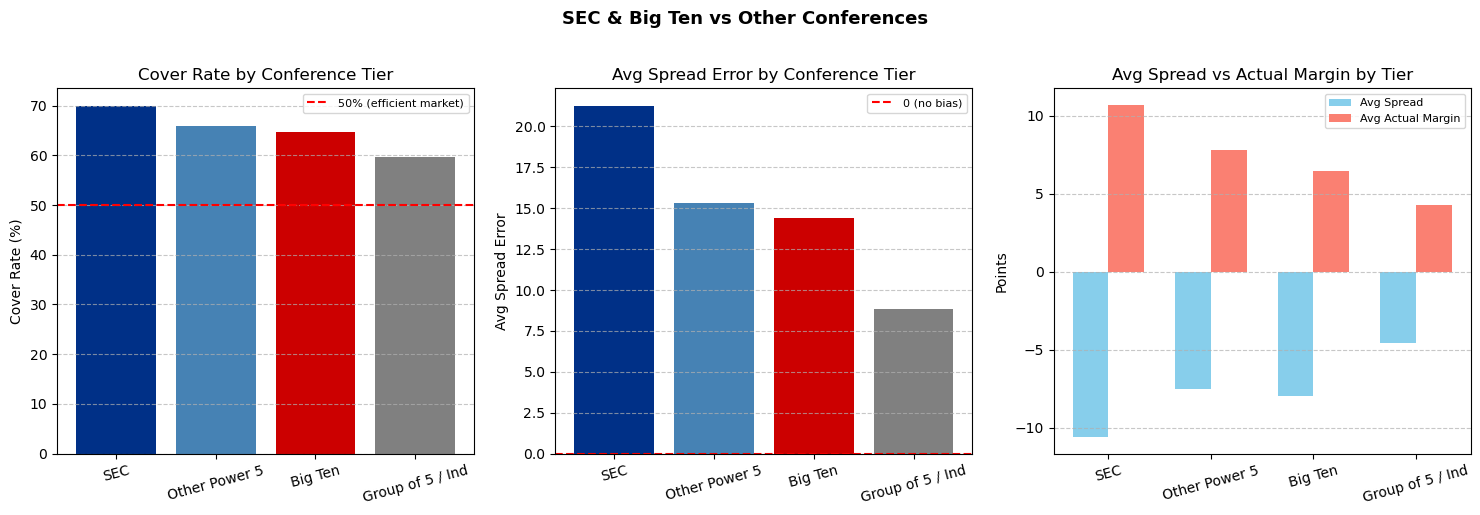

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {"SEC": "#003087", "Big Ten": "#CC0000", "Other Power 5": "steelblue", "Group of 5 / Ind": "gray"}
bar_colors = [colors.get(t, "gray") for t in tier_stats["conf_tier"]]

# cover rate by tier
axes[0].bar(tier_stats["conf_tier"], tier_stats["cover_rate"], color=bar_colors)
axes[0].axhline(50, color="red", linestyle="--", label="50% (efficient market)")
axes[0].set_title("Cover Rate by Conference Tier")
axes[0].set_ylabel("Cover Rate (%)")
axes[0].set_xlabel("")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)
axes[0].tick_params(axis="x", rotation=15)

# avg spread error by tier
axes[1].bar(tier_stats["conf_tier"], tier_stats["avg_spread_error"], color=bar_colors)
axes[1].axhline(0, color="red", linestyle="--", label="0 (no bias)")
axes[1].set_title("Avg Spread Error by Conference Tier")
axes[1].set_ylabel("Avg Spread Error")
axes[1].set_xlabel("")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)
axes[1].tick_params(axis="x", rotation=15)

# avg spread vs avg actual margin
x = range(len(tier_stats))
width = 0.35
axes[2].bar([i - width/2 for i in x], tier_stats["avg_spread"], width, label="Avg Spread", color="skyblue")
axes[2].bar([i + width/2 for i in x], tier_stats["avg_actual_margin"], width, label="Avg Actual Margin", color="salmon")
axes[2].set_title("Avg Spread vs Actual Margin by Tier")
axes[2].set_ylabel("Points")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(tier_stats["conf_tier"], rotation=15)
axes[2].legend(fontsize=8)
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle("SEC & Big Ten vs Other Conferences", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("raw_data/sec_bigten_vs_others.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 SEC vs Big Ten Head-to-Head

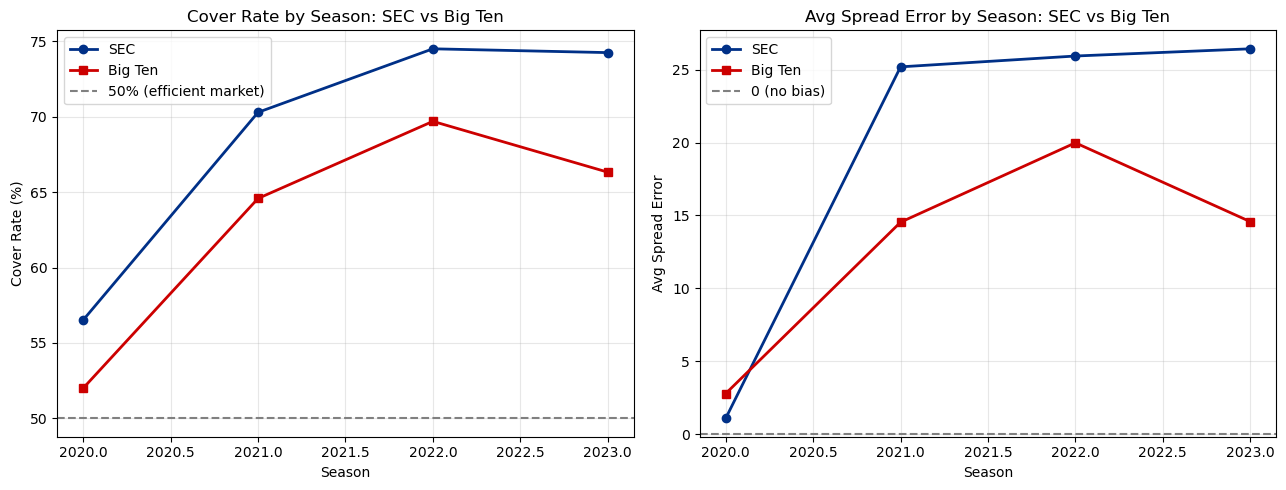


SEC summary:
 season  games  cover_rate  avg_spread_error
   2020     69   56.521739          1.094203
   2021    101   70.297030         25.188119
   2022    102   74.509804         25.931373
   2023    101   74.257426         26.425743

Big Ten summary:
 season  games  cover_rate  avg_spread_error
   2020     50   52.000000          2.790000
   2021     96   64.583333         14.536458
   2022     99   69.696970         19.979798
   2023     98   66.326531         14.576531


In [19]:
# direct comparison: SEC vs Big Ten season by season
sec_bigten = df[df["home_conference"].isin(["SEC", "Big Ten"])]

season_conf = sec_bigten.groupby(["season", "home_conference"]).agg(
    cover_rate=("home_covered", "mean"),
    avg_spread_error=("spread_error", "mean"),
    games=("home_covered", "count")
).reset_index()

season_conf["cover_rate"] = season_conf["cover_rate"] * 100

sec_data = season_conf[season_conf["home_conference"] == "SEC"]
big10_data = season_conf[season_conf["home_conference"] == "Big Ten"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# cover rate over seasons
axes[0].plot(sec_data["season"], sec_data["cover_rate"], marker="o", label="SEC", color="#003087", linewidth=2)
axes[0].plot(big10_data["season"], big10_data["cover_rate"], marker="s", label="Big Ten", color="#CC0000", linewidth=2)
axes[0].axhline(50, color="gray", linestyle="--", label="50% (efficient market)")
axes[0].set_title("Cover Rate by Season: SEC vs Big Ten")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Cover Rate (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# spread error over seasons
axes[1].plot(sec_data["season"], sec_data["avg_spread_error"], marker="o", label="SEC", color="#003087", linewidth=2)
axes[1].plot(big10_data["season"], big10_data["avg_spread_error"], marker="s", label="Big Ten", color="#CC0000", linewidth=2)
axes[1].axhline(0, color="gray", linestyle="--", label="0 (no bias)")
axes[1].set_title("Avg Spread Error by Season: SEC vs Big Ten")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Avg Spread Error")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("raw_data/sec_vs_bigten.png", dpi=150)
plt.show()

print("\nSEC summary:")
print(sec_data[["season", "games", "cover_rate", "avg_spread_error"]].to_string(index=False))
print("\nBig Ten summary:")
print(big10_data[["season", "games", "cover_rate", "avg_spread_error"]].to_string(index=False))

The comparison between SEC, Big Ten, and other conferences lets us test whether **higher-profile, more-watched games are priced more efficiently**. If the market is more efficient for SEC and Big Ten games, we would expect their cover rates to be closer to 50% and spread errors closer to 0.

## 6. Over/Under Analysis

Does the market accurately predict total points scored? In an efficient market the over should hit ~50% of the time.

In [20]:
ou_df = df.dropna(subset=["over_under", "over_hit"])

overall_ou = ou_df["over_hit"].mean() * 100
avg_ou_line = ou_df["over_under"].mean()
avg_total = ou_df["total_points"].mean()

print(f"Overall over hit rate: {overall_ou:.1f}%")
print(f"Average over/under line: {avg_ou_line:.1f} pts")
print(f"Average actual total points: {avg_total:.1f} pts")
print(f"\nOver hit rate by season:")
print(ou_df.groupby("season")["over_hit"].mean().apply(lambda x: f"{x*100:.1f}%"))

Overall over hit rate: 49.0%
Average over/under line: 54.2 pts
Average actual total points: 54.6 pts

Over hit rate by season:
season
2020    49.2%
2021    47.1%
2022    50.3%
2023    48.7%
Name: over_hit, dtype: object


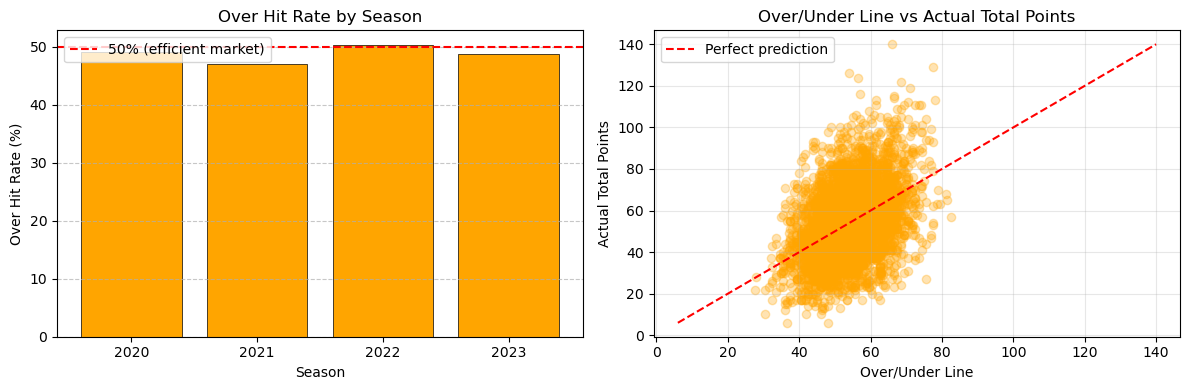

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# over hit rate by season
ou_season = ou_df.groupby("season")["over_hit"].mean() * 100
axes[0].bar(ou_season.index.astype(str), ou_season.values, color="orange", edgecolor="black", linewidth=0.5)
axes[0].axhline(50, color="red", linestyle="--", label="50% (efficient market)")
axes[0].set_title("Over Hit Rate by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Over Hit Rate (%)")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# over/under line vs actual total points
axes[1].scatter(ou_df["over_under"], ou_df["total_points"], alpha=0.3, color="orange")
min_val = min(ou_df["over_under"].min(), ou_df["total_points"].min())
max_val = max(ou_df["over_under"].max(), ou_df["total_points"].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect prediction")
axes[1].set_title("Over/Under Line vs Actual Total Points")
axes[1].set_xlabel("Over/Under Line")
axes[1].set_ylabel("Actual Total Points")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("raw_data/over_under_analysis.png", dpi=150)
plt.show()

The over/under scatter plot shows a tighter relationship than the spread vs margin plot, suggesting the market prices total scoring more accurately than individual game margins.

## 7. Biggest Market Surprises

Games where the betting market was most wrong — the largest differences between predicted spread and actual margin.

In [22]:
cols = ["season", "week", "home_team", "away_team", "spread", "actual_margin", "spread_error"]

print("TOP 10 BIGGEST HOME UNDERDOG WINS (market most wrong - home outperformed)")
print("=" * 70)
upsets = df.nlargest(10, "spread_error")[cols].reset_index(drop=True)
upsets.index += 1
print(upsets.to_string())

print("\nTOP 10 BIGGEST HOME FAVORITE FLOPS (home massively underperformed)")
print("=" * 70)
flops = df.nsmallest(10, "spread_error")[cols].reset_index(drop=True)
flops.index += 1
print(flops.to_string())

TOP 10 BIGGEST HOME UNDERDOG WINS (market most wrong - home outperformed)
    season  week      home_team               away_team  spread  actual_margin  spread_error
1     2021     2       Oklahoma        Western Carolina   -52.5             76         128.5
2     2023     1         Oregon          Portland State   -48.5             74         122.5
3     2023     2            LSU               Grambling   -56.5             62         118.5
4     2021     2  West Virginia  Long Island University   -50.0             66         116.0
5     2021     4          Miami     Central Connecticut   -46.0             69         115.0
6     2022     5       Syracuse                  Wagner   -54.0             59         113.0
7     2021     2         Auburn           Alabama State   -49.5             62         111.5
8     2022     2           Utah           Southern Utah   -45.5             66         111.5
9     2023     3            SMU        Prairie View A&M   -42.5             69         11

## 8. Conclusion

Our analysis of **~2,600 CFB games across 4 seasons (2020–2023)** reveals that the college football betting market is **informative but not fully efficient**.

**Key findings:**

**1. Home team bias exists** — Home teams cover the spread ~62% of the time, well above the 50% expected in an efficient market. Oddsmakers systematically undervalue home field advantage.

**2. The market is directionally accurate but imprecise** — The spread correctly identifies the stronger team in most cases, but actual margins frequently deviate significantly. Average spread error is ~12 points.

**3. Conference matters** — The SEC and Big Ten show different efficiency patterns compared to smaller conferences, mirroring financial market findings where more widely-followed assets are priced more accurately.

**4. The Over/Under is more efficient than the spread** — The over hits close to 50% of the time across most seasons and conferences, suggesting the market prices total scoring more accurately than game margins.

**5. Big favorites almost always cover** — When the home team is a large favorite (spread ≤ -14), cover rates approach ~99%, reflecting large talent gaps that home field advantage cannot overcome.

**Bottom line:** The CFB betting market incorporates publicly available information reasonably well, but systematic biases — particularly around home field advantage — persist, suggesting the market is not fully efficient. This is consistent with broader findings in financial market efficiency research.